# Date Fruit Classification using ResNet-50

This notebook contains a complete deep learning pipeline for classifying date fruit varieties using transfer learning with ResNet-50.

The dataset contains 10 date fruit classes:

- Ajwa
- Aseel
- Fasli-Toto
- Galaxy
- Medjool
- Meneifi
- Nabtat-Ali
- Shaishe
- Sokari
- Sugaey

The goal is to build a multiclass image classification model and understand every major design decision, including dataset splitting, preprocessing, transfer learning, fine-tuning, evaluation, and inference.

## 1. Environment and GPU Verification

Before training any deep learning model, we first verify that PyTorch can access the GPU.

This is important because ResNet-50 training on CPU would be extremely slow, while GPU acceleration makes training practical.

In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("PyTorch CUDA Version:", torch.version.cuda)
else:
    print("GPU is not available. Training will run on CPU.")

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050
PyTorch CUDA Version: 12.8


## 2. Project Configuration

In this section, we define all important project paths and global settings.

In [3]:
from pathlib import Path
import os
import random
import shutil
from collections import Counter

from PIL import Image

# -----------------------------
# Project Root
# -----------------------------
# Path.cwd() means: current folder where this notebook is running.
ROOT = Path.cwd()

# -----------------------------
# Dataset Paths
# -----------------------------
DATASET_DIR = ROOT / "datasets"

# Full dataset contains original class folders.
FULL_DIR = DATASET_DIR / "full"

# These folders will be created automatically.
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

# -----------------------------
# Allowed image formats
# -----------------------------
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Project Root:", ROOT)
print("Full Dataset Path:", FULL_DIR)
print("Train Path:", TRAIN_DIR)
print("Validation Path:", VAL_DIR)
print("Test Path:", TEST_DIR)

Project Root: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project
Full Dataset Path: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\datasets\full
Train Path: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\datasets\train
Validation Path: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\datasets\val
Test Path: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\datasets\test


## 3. Set Random Seed

Machine learning experiments involve randomness.

For example:

- dataset shuffling
- train/validation/test splitting
- model weight initialization
- data augmentation

Setting a seed helps make our experiment more reproducible.

In [4]:
def set_seed(seed: int = 42):
    """
    Sets random seed for Python and PyTorch.

    This helps make dataset splitting and training behavior more reproducible.
    """
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Useful for fixed image sizes.
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


## 4. Dataset Audit

Before splitting or training, we inspect the dataset.

We check:

1. Number of classes
2. Number of images per class
3. Total number of images
4. Whether class folders are correctly detected

This step is important because many deep learning problems come from dataset mistakes, not model mistakes.

In [5]:
# Detect class folders inside datasets/full
classes = sorted([folder.name for folder in FULL_DIR.iterdir() if folder.is_dir()])

print("Classes Found:")
for cls in classes:
    print("-", cls)

print("\nNumber of Classes:", len(classes))

# Count images per class
class_counts = {}

for cls in classes:
    class_dir = FULL_DIR / cls

    image_paths = [
        path for path in class_dir.rglob("*")
        if path.suffix.lower() in IMG_EXTENSIONS
    ]

    class_counts[cls] = len(image_paths)

print("\nImage Count Per Class:")
for cls, count in class_counts.items():
    print(f"{cls:15s}: {count}")

print("\nTotal Images:", sum(class_counts.values()))

Classes Found:
- Ajwa
- Aseel
- Fasli-Toto
- Galaxy
- Medjool
- Meneifi
- Nabtat-Ali
- Shaishe
- Sokari
- Sugaey

Number of Classes: 10

Image Count Per Class:
Ajwa           : 700
Aseel          : 700
Fasli-Toto     : 700
Galaxy         : 700
Medjool        : 700
Meneifi        : 700
Nabtat-Ali     : 700
Shaishe        : 700
Sokari         : 700
Sugaey         : 700

Total Images: 7000


## 5. Corrupted Image Check

Sometimes datasets contain broken or unreadable images.

A corrupted image can stop training in the middle of an epoch.

So before training, we verify that all images can be opened properly.

In [6]:
bad_images = []

for cls in classes:
    class_dir = FULL_DIR / cls

    image_paths = [
        path for path in class_dir.rglob("*")
        if path.suffix.lower() in IMG_EXTENSIONS
    ]

    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as error:
            bad_images.append((img_path, str(error)))

print("Bad Images Found:", len(bad_images))

if bad_images:
    print("\nFirst few bad images:")
    for path, error in bad_images[:20]:
        print(path, "=>", error)

Bad Images Found: 0


## 6. Train / Validation / Test Split

We split the dataset into three parts:

- 70% Training data
- 15% Validation data
- 15% Test data

### Why three splits?

Training data is used to update model weights.

Validation data is used during development to tune decisions such as augmentation, learning rate, and fine-tuning strategy.

Test data is used only at the end as the final honest evaluation.

The model should not learn from validation or test data.

In [7]:
def hardlink_or_copy(src: Path, dst: Path):
    """
    Creates a hardlink if possible.
    
    A hardlink saves disk space because it does not duplicate the actual image file.
    If hardlinking fails, the function falls back to normal copying.
    """
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists():
        return

    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)


def split_dataset(
    full_dir: Path,
    train_dir: Path,
    val_dir: Path,
    test_dir: Path,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    seed: int = 42,
    recreate: bool = False
):
    """
    Splits image dataset from datasets/full into train, val, and test folders.

    Expected input structure:

    datasets/full/
        Ajwa/
        Aseel/
        Fasli-Toto/
        ...

    Output structure:

    datasets/train/
        Ajwa/
        Aseel/
        ...

    datasets/val/
        Ajwa/
        Aseel/
        ...

    datasets/test/
        Ajwa/
        Aseel/
        ...
    """

    # Safety check: ratios must add up to 1.
    total_ratio = train_ratio + val_ratio + test_ratio
    assert abs(total_ratio - 1.0) < 1e-6, "Split ratios must add up to 1."

    # If recreate=True, old split folders are deleted and rebuilt.
    if recreate:
        for folder in [train_dir, val_dir, test_dir]:
            if folder.exists():
                shutil.rmtree(folder)

    # Prevent accidental re-splitting if folders already contain data.
    split_folders_have_data = any([
        train_dir.exists() and any(train_dir.iterdir()),
        val_dir.exists() and any(val_dir.iterdir()),
        test_dir.exists() and any(test_dir.iterdir())
    ])

    if split_folders_have_data and not recreate:
        print("Split folders already contain data.")
        print("No changes made.")
        print("To rebuild the split, call this function with recreate=True.")
        return

    rng = random.Random(seed)

    classes = sorted([folder.name for folder in full_dir.iterdir() if folder.is_dir()])

    print("Creating dataset split...\n")

    for cls in classes:
        source_class_dir = full_dir / cls

        image_paths = [
            path for path in source_class_dir.rglob("*")
            if path.suffix.lower() in IMG_EXTENSIONS
        ]

        # Shuffle images in a reproducible way.
        rng.shuffle(image_paths)

        total_images = len(image_paths)

        train_count = int(total_images * train_ratio)
        val_count = int(total_images * val_ratio)

        train_images = image_paths[:train_count]
        val_images = image_paths[train_count:train_count + val_count]
        test_images = image_paths[train_count + val_count:]

        # Copy or hardlink images to split folders.
        for img_path in train_images:
            destination = train_dir / cls / img_path.name
            hardlink_or_copy(img_path, destination)

        for img_path in val_images:
            destination = val_dir / cls / img_path.name
            hardlink_or_copy(img_path, destination)

        for img_path in test_images:
            destination = test_dir / cls / img_path.name
            hardlink_or_copy(img_path, destination)

        print(
            f"{cls:15s} | "
            f"Train: {len(train_images):4d} | "
            f"Val: {len(val_images):4d} | "
            f"Test: {len(test_images):4d} | "
            f"Total: {total_images:4d}"
        )

    print("\nDataset split completed.")


split_dataset(
    full_dir=FULL_DIR,
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    test_dir=TEST_DIR,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED,
    recreate=False
)

Creating dataset split...

Ajwa            | Train:  489 | Val:  105 | Test:  106 | Total:  700
Aseel           | Train:  489 | Val:  105 | Test:  106 | Total:  700
Fasli-Toto      | Train:  489 | Val:  105 | Test:  106 | Total:  700
Galaxy          | Train:  489 | Val:  105 | Test:  106 | Total:  700
Medjool         | Train:  489 | Val:  105 | Test:  106 | Total:  700
Meneifi         | Train:  489 | Val:  105 | Test:  106 | Total:  700
Nabtat-Ali      | Train:  489 | Val:  105 | Test:  106 | Total:  700
Shaishe         | Train:  489 | Val:  105 | Test:  106 | Total:  700
Sokari          | Train:  489 | Val:  105 | Test:  106 | Total:  700
Sugaey          | Train:  489 | Val:  105 | Test:  106 | Total:  700

Dataset split completed.


## 7. Verify Split Counts

After creating the split, we verify that train, validation, and test folders contain the expected number of images.

This confirms that the dataset split was successful.

In [8]:
def count_images_in_split(split_dir: Path):
    """
    Counts images per class in a given split folder.
    """
    counts = {}

    if not split_dir.exists():
        return counts

    classes = sorted([folder.name for folder in split_dir.iterdir() if folder.is_dir()])

    for cls in classes:
        class_dir = split_dir / cls

        image_paths = [
            path for path in class_dir.rglob("*")
            if path.suffix.lower() in IMG_EXTENSIONS
        ]

        counts[cls] = len(image_paths)

    return counts


train_counts = count_images_in_split(TRAIN_DIR)
val_counts = count_images_in_split(VAL_DIR)
test_counts = count_images_in_split(TEST_DIR)

print("Split Verification:\n")

for cls in classes:
    print(
        f"{cls:15s} | "
        f"Train: {train_counts.get(cls, 0):4d} | "
        f"Val: {val_counts.get(cls, 0):4d} | "
        f"Test: {test_counts.get(cls, 0):4d}"
    )

print("\nTotal Train Images:", sum(train_counts.values()))
print("Total Val Images:", sum(val_counts.values()))
print("Total Test Images:", sum(test_counts.values()))

Split Verification:

Ajwa            | Train:  489 | Val:  105 | Test:  106
Aseel           | Train:  489 | Val:  105 | Test:  106
Fasli-Toto      | Train:  489 | Val:  105 | Test:  106
Galaxy          | Train:  489 | Val:  105 | Test:  106
Medjool         | Train:  489 | Val:  105 | Test:  106
Meneifi         | Train:  489 | Val:  105 | Test:  106
Nabtat-Ali      | Train:  489 | Val:  105 | Test:  106
Shaishe         | Train:  489 | Val:  105 | Test:  106
Sokari          | Train:  489 | Val:  105 | Test:  106
Sugaey          | Train:  489 | Val:  105 | Test:  106

Total Train Images: 4890
Total Val Images: 1050
Total Test Images: 1060


## 8. Image Preprocessing and Data Augmentation

Before feeding images into ResNet-50, we need to transform them into a standard format.

ResNet-50 expects images in this form:

- RGB image
- Fixed input size
- Tensor format
- Normalized using ImageNet mean and standard deviation

Since we are using a pretrained ResNet-50 model, we use the same normalization style used during ImageNet training.

For training data, we apply light augmentation to improve generalization.

For validation and test data, we do not apply random augmentation because evaluation should be stable and honest.

In [10]:
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 9. Define Transformations

There are two different transformation pipelines:

### Training Transformations

Used for the training set.

These include light random changes such as:

- random cropping
- small rotation
- horizontal flipping
- small color changes

The goal is to make the model robust.

### Evaluation Transformations

Used for validation and test sets.

These must be deterministic, meaning no randomness.

The goal is to measure model performance fairly.

In [11]:
# -----------------------------
# ImageNet Normalization Values
# -----------------------------
# These values are used because ResNet-50 pretrained weights were trained on ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# -----------------------------
# Image Size
# -----------------------------
# Standard ResNet input size is 224x224.
IMAGE_SIZE = 224

# -----------------------------
# Training Transformations
# -----------------------------
# These transformations are applied only to training images.
# They help the model generalize better and avoid memorizing exact images.
train_transforms = transforms.Compose([
    # First resize the image slightly larger than final input size.
    transforms.Resize((256, 256)),

    # Random crop creates small position and scale variation.
    # scale=(0.80, 1.0) means crop between 80% and 100% of resized image area.
    # ratio=(0.90, 1.10) avoids extreme shape distortion.
    transforms.RandomResizedCrop(
        size=IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10)
    ),

    # Horizontal flip is safe because flipping a date fruit usually does not change its class.
    transforms.RandomHorizontalFlip(p=0.5),

    # Small rotation helps the model handle angle variation.
    # fill=255 keeps the background white when rotation creates empty corners.
    transforms.RandomRotation(degrees=10, fill=255),

    # Slight color variation helps handle lighting differences.
    # Keep it mild because date color is an important classification clue.
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.08,
        hue=0.02
    ),

    # Convert PIL image to PyTorch tensor.
    transforms.ToTensor(),

    # Normalize image using ImageNet mean and standard deviation.
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# -----------------------------
# Validation/Test Transformations
# -----------------------------
# No random augmentation here.
# Validation and test evaluation should be stable.
eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training transforms:")
print(train_transforms)

print("\nEvaluation transforms:")
print(eval_transforms)

Training transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=255)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.92, 1.08), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 10. Load Dataset using ImageFolder

PyTorch's ImageFolder automatically assigns labels based on folder names.

Expected folder structure:

datasets/train/
    Ajwa/
    Aseel/
    Fasli-Toto/
    ...

datasets/val/
    Ajwa/
    Aseel/
    Fasli-Toto/
    ...

datasets/test/
    Ajwa/
    Aseel/
    Fasli-Toto/
    ...

Each class folder becomes one label.

In [12]:
# -----------------------------
# Create PyTorch datasets
# -----------------------------
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=eval_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transforms
)

# -----------------------------
# Print basic dataset information
# -----------------------------
print("Classes:")
for idx, class_name in enumerate(train_dataset.classes):
    print(f"{idx}: {class_name}")

print("\nClass to Index Mapping:")
print(train_dataset.class_to_idx)

print("\nDataset Sizes:")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

# Safety check:
# All splits should have the same class order.
assert train_dataset.classes == val_dataset.classes == test_dataset.classes

print("\nClass order is consistent across train, val, and test.")

Classes:
0: Ajwa
1: Aseel
2: Fasli-Toto
3: Galaxy
4: Medjool
5: Meneifi
6: Nabtat-Ali
7: Shaishe
8: Sokari
9: Sugaey

Class to Index Mapping:
{'Ajwa': 0, 'Aseel': 1, 'Fasli-Toto': 2, 'Galaxy': 3, 'Medjool': 4, 'Meneifi': 5, 'Nabtat-Ali': 6, 'Shaishe': 7, 'Sokari': 8, 'Sugaey': 9}

Dataset Sizes:
Train: 4890
Val: 1050
Test: 1060

Class order is consistent across train, val, and test.


## 11. Create DataLoaders

A DataLoader feeds images to the model in mini-batches.

Instead of loading all images at once, we load small batches such as 16 images at a time.

This is important because GPU memory is limited.

For RTX 3050 Laptop GPU, batch size 16 is a safe starting point for ResNet-50.

In [13]:
# -----------------------------
# DataLoader Configuration
# -----------------------------
BATCH_SIZE = 16

# On Windows + Jupyter, num_workers=0 is the safest option.
# Later, if everything works, we can try 2 or 4 for speed.
NUM_WORKERS = 0

# pin_memory=True can speed up CPU-to-GPU transfer when using CUDA.
PIN_MEMORY = torch.cuda.is_available()

# -----------------------------
# Create DataLoaders
# -----------------------------
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("DataLoaders created successfully.")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Train batches: 306
Val batches: 66
Test batches: 67


## 12. Inspect One Batch

Before training, we visualize a batch of transformed images.

This step is extremely important.

If images look wrong here, then the model will also receive wrong input.

We check:

- Are images visible?
- Are labels correct?
- Are colors natural after denormalization?
- Are augmentations reasonable?
- Are dates not overly cropped or distorted?

In [15]:
# Denormalization Helper
def denormalize_image(tensor_image):
    """
    Converts a normalized tensor image back to normal image range for visualization.

    Input shape:
        [C, H, W]

    Output shape:
        [H, W, C]
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = tensor_image.cpu() * std + mean

    # Keep values between 0 and 1 for matplotlib.
    image = image.clamp(0, 1)

    # Convert from [C, H, W] to [H, W, C]
    image = image.permute(1, 2, 0)

    return image

Batch image tensor shape: torch.Size([16, 3, 224, 224])
Batch label tensor shape: torch.Size([16])


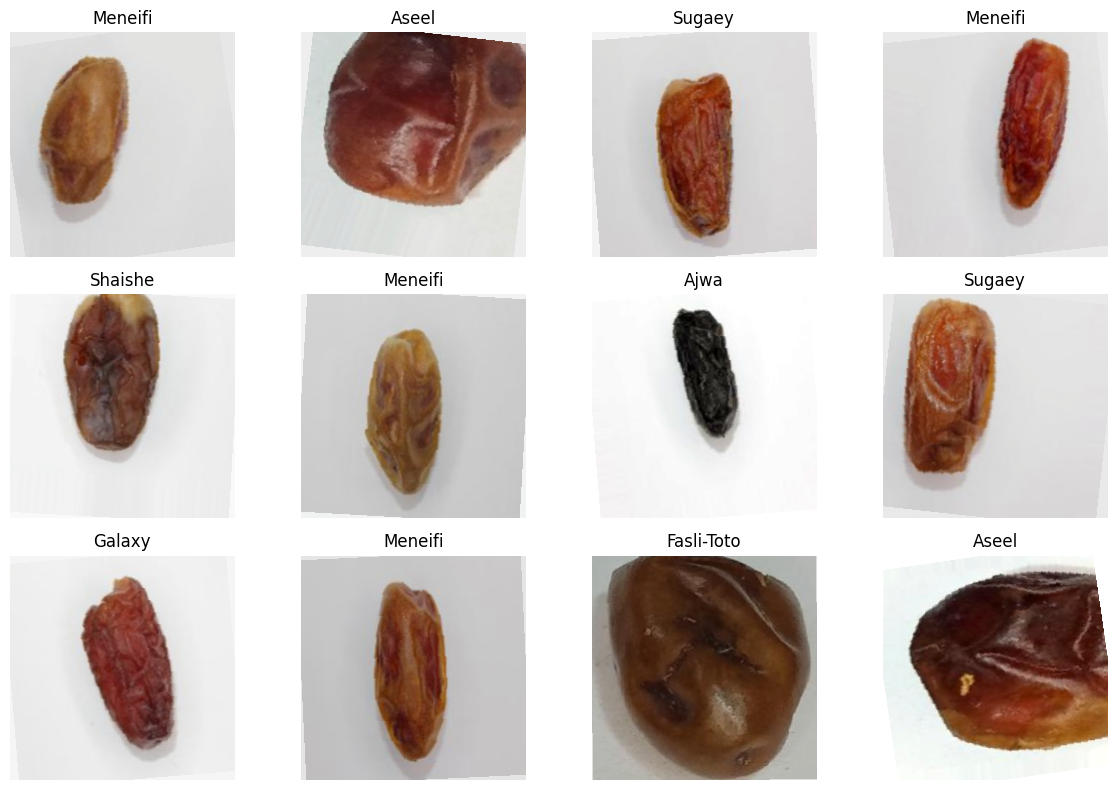

In [17]:
# Visualize Training Batch
# Get one batch from the training loader
images, labels = next(iter(train_loader))

print("Batch image tensor shape:", images.shape)
print("Batch label tensor shape:", labels.shape)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    image = denormalize_image(images[i])
    label_index = labels[i].item()
    label_name = train_dataset.classes[label_index]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Check One Image Before and After Augmentation

This helps us understand how training augmentation changes the image.

The model sees a slightly different version of the same image during training, which helps it generalize better.

Sample image path: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\datasets\train\Ajwa\Ajwa Date (10).JPG
Class: Ajwa


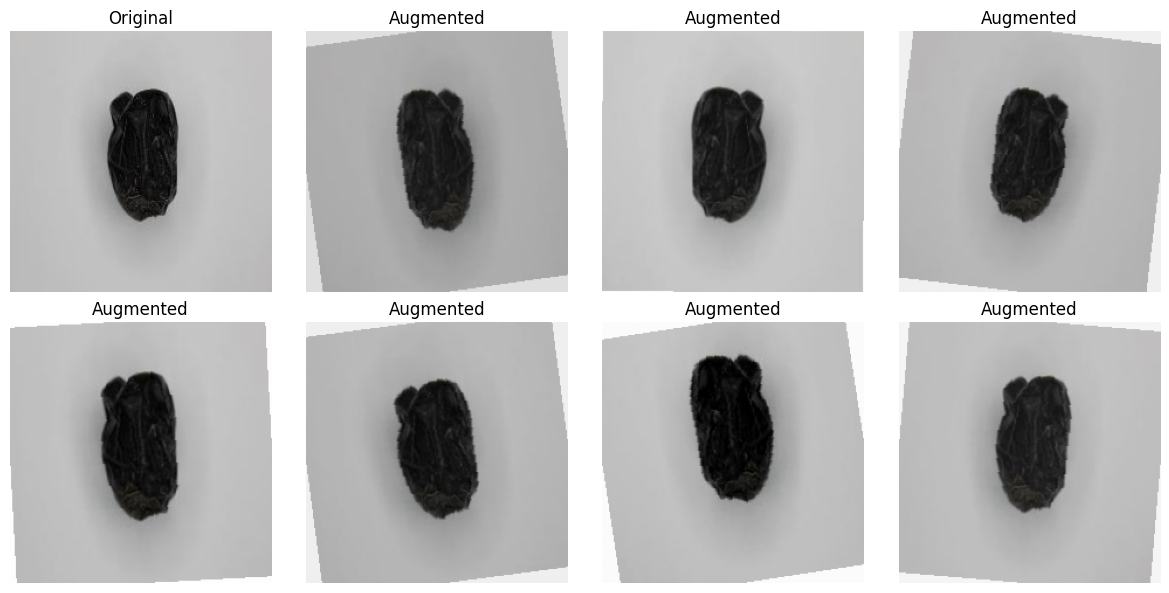

In [18]:
# Pick the first image from the training dataset samples
sample_path, sample_label = train_dataset.samples[0]

print("Sample image path:", sample_path)
print("Class:", train_dataset.classes[sample_label])

# Load original image
original_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(12, 6))

# Show original image
plt.subplot(2, 4, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

# Show 7 augmented versions
for i in range(2, 9):
    augmented_tensor = train_transforms(original_image)
    augmented_image = denormalize_image(augmented_tensor)

    plt.subplot(2, 4, i)
    plt.imshow(augmented_image)
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. ResNet-50 Transfer Learning Setup

In this section, we prepare ResNet-50 for our date fruit classification task.

ResNet-50 was originally trained on ImageNet, where it learned to classify 1000 general object categories.

Our task has only 10 classes:

- Ajwa
- Aseel
- Fasli-Toto
- Galaxy
- Medjool
- Meneifi
- Nabtat-Ali
- Shaishe
- Sokari
- Sugaey

So we keep the pretrained ResNet-50 feature extractor and replace its final classification layer.

This is called transfer learning.

## 15. Why Transfer Learning?

Training a deep CNN like ResNet-50 from scratch requires a very large dataset and high computational power.

Instead, we use a ResNet-50 model pretrained on ImageNet.

The early and middle layers of ResNet-50 already know useful visual patterns such as:

- edges
- curves
- corners
- textures
- object boundaries
- color patterns
- shape patterns

These features are useful for date fruit classification too.

We only replace the final classification head so the model predicts our 10 date classes instead of ImageNet's 1000 classes.

In [19]:
import torch
import torch.nn as nn

from torchvision import models

## 16. Select Device

We select GPU if CUDA is available.

The model and image batches must be on the same device.

If the model is on GPU but images are on CPU, PyTorch will raise an error.

In [20]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 17. Load Pretrained ResNet-50

We load ResNet-50 with pretrained ImageNet weights.

The first time this cell runs, PyTorch may download the pretrained weights.

If the download fails, it usually means the system has no internet access or PyTorch cannot reach the model weight server.

In [21]:
# Load pretrained ResNet-50 weights.
weights = models.ResNet50_Weights.DEFAULT

# Create ResNet-50 model with pretrained weights.
model = models.resnet50(weights=weights)

print("Pretrained ResNet-50 loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\PC/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Pretrained ResNet-50 loaded successfully.


## 18. Understand the Original Final Layer

The original ResNet-50 model was trained on ImageNet.

Therefore, its final layer predicts 1000 classes.

For our project, this final layer must be replaced because we only have 10 date fruit classes.

In [22]:
print("Original final layer:")
print(model.fc)

print("\nInput features to final layer:", model.fc.in_features)
print("Output classes from original final layer:", model.fc.out_features)

Original final layer:
Linear(in_features=2048, out_features=1000, bias=True)

Input features to final layer: 2048
Output classes from original final layer: 1000


## 19. Replace the Classification Head

The ResNet-50 backbone outputs a 2048-dimensional feature vector.

We replace the original ImageNet classifier with a new classifier for our 10 date classes.

The new classification head is:

Dropout -> Linear Layer

Dropout helps reduce overfitting by randomly disabling some features during training.

The final Linear layer maps 2048 features to 10 class scores.

In [23]:
# Number of classes in our dataset
NUM_CLASSES = len(train_dataset.classes)

# Number of input features coming into the original final layer
in_features = model.fc.in_features

# Replace final ImageNet classifier with our custom classifier
model.fc = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

print("New final classification head:")
print(model.fc)

print("\nNumber of classes:", NUM_CLASSES)

New final classification head:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=10, bias=True)
)

Number of classes: 10


## 20. Move Model to GPU

Now we move the model to the selected device.

Since CUDA is available, the model will be moved to the NVIDIA GPU.

In [24]:
model = model.to(DEVICE)

print("Model moved to:", DEVICE)

Model moved to: cuda


## 21. Freeze the ResNet Backbone

In the first training stage, we freeze the pretrained ResNet-50 backbone.

This means the convolutional feature extractor will not update its weights.

Only the new classification head will learn.

This is useful because:

1. It trains faster.
2. It uses less GPU memory.
3. It reduces the risk of damaging pretrained features early.
4. It gives us a stable baseline before fine-tuning.

In [25]:
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the final classification head
for param in model.fc.parameters():
    param.requires_grad = True

print("Backbone frozen.")
print("Only final classification head is trainable.")

Backbone frozen.
Only final classification head is trainable.


## 22. Count Trainable Parameters

We count total parameters and trainable parameters.

This helps us confirm that freezing worked correctly.

If freezing is correct, only the final classification head should be trainable.

In [26]:
def count_parameters(model):
    """
    Counts total and trainable parameters in the model.
    """
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

    return total_params, trainable_params


total_params, trainable_params = count_parameters(model)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     23,528,522
Trainable parameters: 20,490
Frozen parameters:    23,508,032


## 23. Check Which Layers Are Trainable

This cell prints the parameters that are currently trainable.

At this stage, only the final classifier parameters should be trainable.

In [27]:
print("Trainable parameters:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable parameters:

fc.1.weight torch.Size([10, 2048])
fc.1.bias torch.Size([10])


## 24. Forward Pass Sanity Check

Before training, we test whether one image batch can successfully pass through the model.

This confirms:

1. Image shape is correct.
2. Model is on the correct device.
3. Output shape is correct.
4. The final classifier produces 10 scores per image.

For batch size 16 and 10 classes, expected output shape is:

[16, 10]

In [28]:
# Get one batch from the training loader
images, labels = next(iter(train_loader))

# Move images and labels to GPU/CPU device
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Set model to evaluation mode for this test
model.eval()

# Disable gradient calculation because this is only a sanity check
with torch.no_grad():
    outputs = model(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)
print("Label batch shape:", labels.shape)

Input batch shape: torch.Size([16, 3, 224, 224])
Output batch shape: torch.Size([16, 10])
Label batch shape: torch.Size([16])


## 25. Convert Logits to Probabilities

The model output is not directly probability.

The output values are logits.

To convert logits into probabilities, we apply softmax.

During training, CrossEntropyLoss expects raw logits, so we do not apply softmax manually inside training.

But for understanding and inference, softmax helps us see the predicted confidence per class.

In [29]:
# Convert logits to probabilities
probabilities = torch.softmax(outputs, dim=1)

# Get highest probability and predicted class index
confidence_scores, predicted_indices = torch.max(probabilities, dim=1)

print("Predictions from randomly initialized classification head:\n")

for i in range(min(5, len(images))):
    true_index = labels[i].item()
    pred_index = predicted_indices[i].item()
    confidence = confidence_scores[i].item()

    true_class = train_dataset.classes[true_index]
    pred_class = train_dataset.classes[pred_index]

    print(
        f"Image {i+1}: "
        f"True = {true_class:12s} | "
        f"Predicted = {pred_class:12s} | "
        f"Confidence = {confidence:.4f}"
    )

Predictions from randomly initialized classification head:

Image 1: True = Meneifi      | Predicted = Ajwa         | Confidence = 0.1468
Image 2: True = Meneifi      | Predicted = Ajwa         | Confidence = 0.1415
Image 3: True = Sugaey       | Predicted = Ajwa         | Confidence = 0.1505
Image 4: True = Sugaey       | Predicted = Ajwa         | Confidence = 0.1682
Image 5: True = Galaxy       | Predicted = Ajwa         | Confidence = 0.1462


## 26. Training Setup for Frozen-Backbone Transfer Learning

Now we prepare the first training stage.

In this stage:

- The pretrained ResNet-50 backbone remains frozen.
- Only the new classification head is trained.
- This gives us a stable baseline before fine-tuning deeper layers.

This stage is useful because the pretrained backbone already knows general visual features, while the new classifier head needs to learn how to map those features to our 10 date fruit classes.

In [30]:
# -----------------------------
# Checkpoint Directory
# -----------------------------
# Model checkpoints will be saved here.
CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Checkpoint directory: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints


## 27. Loss Function, Optimizer, and Scheduler

For multiclass classification, we use CrossEntropyLoss.

CrossEntropyLoss expects raw logits from the model, not softmax probabilities.

The optimizer updates only the trainable parameters, which currently belong to the final classification head.

We also use a learning rate scheduler to reduce the learning rate if validation loss stops improving.

In [32]:
# -----------------------------
# Loss Function
# -----------------------------
# CrossEntropyLoss is standard for multiclass classification.
criterion = nn.CrossEntropyLoss()

# -----------------------------
# Optimizer
# -----------------------------
# Since the backbone is frozen, we optimize only model.fc parameters.
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# -----------------------------
# Learning Rate Scheduler
# -----------------------------
# If validation loss stops improving, reduce learning rate.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x000002658E952600>


## 28. Training Function

This function trains the model for one epoch.

One epoch means the model has seen the full training dataset once.

During training:

1. Images are passed through the model.
2. Loss is calculated.
3. Gradients are computed using backpropagation.
4. Optimizer updates trainable weights.
5. Accuracy is tracked.

We use mixed precision training on CUDA to reduce GPU memory usage and speed up training.

In [33]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    """
    Trains the model for one epoch.

    Args:
        model: PyTorch model.
        data_loader: Training DataLoader.
        optimizer: Optimizer used to update trainable parameters.
        criterion: Loss function.
        device: CPU or CUDA device.

    Returns:
        average_loss: Average training loss for the epoch.
        accuracy: Training accuracy for the epoch.
    """

    # Set model to training mode.
    # This enables dropout and other training-specific behavior.
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Mixed precision scaler.
    # Enabled only when CUDA is available.
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    for batch_index, (images, labels) in enumerate(data_loader):
        # Move images and labels to GPU/CPU.
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear old gradients.
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision.
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backward pass.
        scaler.scale(loss).backward()

        # Optimizer step.
        scaler.step(optimizer)

        # Update scaler.
        scaler.update()

        # Track loss.
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        # Track accuracy.
        predicted_classes = outputs.argmax(dim=1)
        correct_predictions += (predicted_classes == labels).sum().item()
        total_samples += batch_size

    average_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## 29. Validation Function

Validation checks how well the model performs on unseen validation data.

During validation:

- We do not update weights.
- We disable gradient calculation.
- We keep evaluation deterministic.

Validation helps us detect overfitting and decide whether the model is improving.

In [34]:
@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    """
    Evaluates the model on validation or test data.

    Args:
        model: PyTorch model.
        data_loader: Validation or test DataLoader.
        criterion: Loss function.
        device: CPU or CUDA device.

    Returns:
        average_loss: Average loss.
        accuracy: Accuracy score.
    """

    # Set model to evaluation mode.
    # This disables dropout randomness.
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        predicted_classes = outputs.argmax(dim=1)
        correct_predictions += (predicted_classes == labels).sum().item()
        total_samples += batch_size

    average_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## 30. Train Frozen Classifier Head

Now we train only the new classification head.

Recommended first run:

- 5 epochs
- Frozen ResNet-50 backbone
- Train only final classifier

This is not the final model yet. It is our first baseline.

In [36]:
import time

In [37]:
# -----------------------------
# Frozen Training Configuration
# -----------------------------
EPOCHS_FROZEN = 5

best_val_accuracy = 0.0

best_frozen_checkpoint_path = CHECKPOINT_DIR / "best_resnet50_frozen.pt"

# Store metrics for plotting later.
frozen_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Starting frozen-backbone training...\n")

for epoch in range(1, EPOCHS_FROZEN + 1):
    start_time = time.time()

    # Train for one epoch.
    train_loss, train_acc = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    # Validate after training epoch.
    val_loss, val_acc = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # Scheduler checks validation loss.
    scheduler.step(val_loss)

    # Save metrics.
    frozen_history["train_loss"].append(train_loss)
    frozen_history["train_acc"].append(train_acc)
    frozen_history["val_loss"].append(val_loss)
    frozen_history["val_acc"].append(val_acc)

    epoch_time = time.time() - start_time

    # Print epoch summary.
    print(
        f"Epoch [{epoch}/{EPOCHS_FROZEN}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save best model based on validation accuracy.
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "classes": train_dataset.classes,
            "val_accuracy": val_acc,
            "image_size": IMAGE_SIZE,
            "imagenet_mean": IMAGENET_MEAN,
            "imagenet_std": IMAGENET_STD,
            "training_stage": "frozen_backbone"
        }, best_frozen_checkpoint_path)

        print(f"Saved best frozen checkpoint: {best_frozen_checkpoint_path}")

print("\nFrozen training completed.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Starting frozen-backbone training...



C:\Users\PC\AppData\Local\Temp\ipykernel_23140\2371828818.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
C:\Users\PC\AppData\Local\Temp\ipykernel_23140\2371828818.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch [1/5] | Train Loss: 1.3031 | Train Acc: 0.6544 | Val Loss: 0.8167 | Val Acc: 0.8286 | Time: 73.0s
Saved best frozen checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_frozen.pt
Epoch [2/5] | Train Loss: 0.7439 | Train Acc: 0.8037 | Val Loss: 0.6133 | Val Acc: 0.8667 | Time: 42.3s
Saved best frozen checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_frozen.pt
Epoch [3/5] | Train Loss: 0.6192 | Train Acc: 0.8305 | Val Loss: 0.5319 | Val Acc: 0.8733 | Time: 42.2s
Saved best frozen checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_frozen.pt
Epoch [4/5] | Train Loss: 0.5556 | Train Acc: 0.8323 | Val Loss: 0.4460 | Val Acc: 0.8838 | Time: 40.9s
Saved best frozen checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_frozen.pt
Epoch [5/5] | Train Loss: 0.5113 | Train Acc: 0.8485 | Val Loss: 0.4263 | Val Acc: 0.8886 | Time: 39.4s
Saved best frozen checkpoint: c:\Users\PC\De

## 31. Plot Frozen Training Curves

Training curves help us understand learning behavior.

We inspect:

- training loss
- validation loss
- training accuracy
- validation accuracy

These curves tell us whether the model is learning, underfitting, or overfitting.

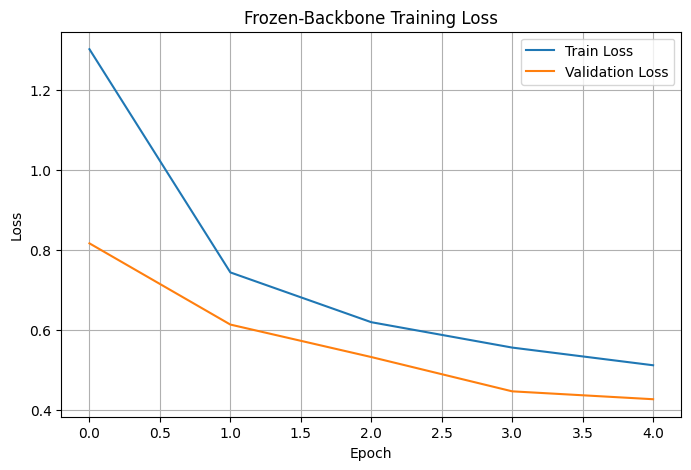

In [40]:
# Plot Loss Curves
plt.figure(figsize=(8, 5))

plt.plot(frozen_history["train_loss"], label="Train Loss")
plt.plot(frozen_history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen-Backbone Training Loss")
plt.legend()
plt.grid(True)
plt.show()

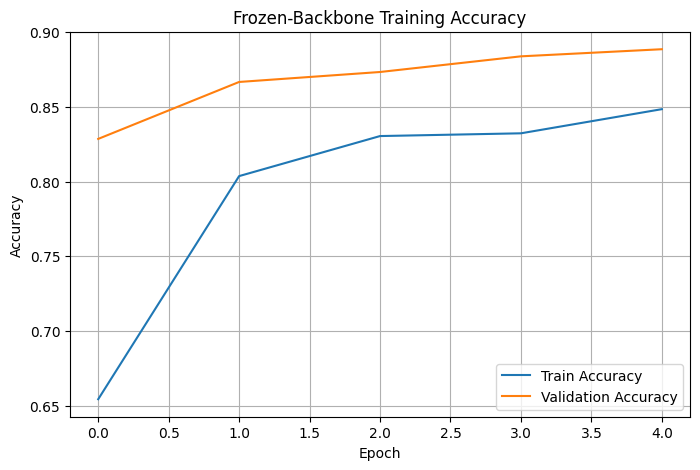

In [42]:
# Plot Accuracy Curves
plt.figure(figsize=(8, 5))

plt.plot(frozen_history["train_acc"], label="Train Accuracy")
plt.plot(frozen_history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frozen-Backbone Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 32. Fine-Tuning Strategy

The frozen-backbone model gave us a strong baseline.

Now we fine-tune the model by unfreezing the last major ResNet block: `layer4`.

ResNet-50 has several major stages:

- conv1
- layer1
- layer2
- layer3
- layer4
- fc

The early layers learn general features such as edges, curves, and simple textures.

The deeper layers learn more task-specific patterns.

For date fruit classification, `layer4` can learn more specialized visual features such as:

- date skin texture
- wrinkle patterns
- fruit shape differences
- class-specific color and surface cues

We keep earlier layers frozen and train only:

- layer4
- final classification head

## 33. Load Best Frozen Checkpoint

Before fine-tuning, we load the best model from the frozen-backbone stage.

This ensures fine-tuning starts from the best frozen model, not from a weaker epoch.

In [43]:
# Load the best checkpoint from frozen-backbone training
checkpoint = torch.load(
    best_frozen_checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best frozen checkpoint.")
print("Best frozen validation accuracy:", checkpoint["val_accuracy"])
print("Checkpoint epoch:", checkpoint["epoch"])

Loaded best frozen checkpoint.
Best frozen validation accuracy: 0.8885714285714286
Checkpoint epoch: 5


## 34. Unfreeze `layer4` and Classification Head

For fine-tuning, we freeze the whole model first.

Then we selectively unfreeze:

- `layer4`
- `fc`

This gives us controlled fine-tuning.

In [44]:
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze final classification head
for param in model.fc.parameters():
    param.requires_grad = True

print("Fine-tuning setup completed.")
print("Trainable parts: layer4 + fc")

Fine-tuning setup completed.
Trainable parts: layer4 + fc


## 35. Count Trainable Parameters After Unfreezing

Now we count trainable parameters again.

This confirms that `layer4` and `fc` are trainable while earlier ResNet layers remain frozen.

In [45]:
total_params, trainable_params = count_parameters(model)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     23,528,522
Trainable parameters: 14,985,226
Frozen parameters:    8,543,296


## 36. Print Trainable Layers

This confirms which model layers will update during fine-tuning.

Expected trainable layers should belong to:

- layer4
- fc

In [46]:
print("Trainable parameters:\n")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable parameters:

layer4.0.conv1.weight torch.Size([512, 1024, 1, 1])
layer4.0.bn1.weight torch.Size([512])
layer4.0.bn1.bias torch.Size([512])
layer4.0.conv2.weight torch.Size([512, 512, 3, 3])
layer4.0.bn2.weight torch.Size([512])
layer4.0.bn2.bias torch.Size([512])
layer4.0.conv3.weight torch.Size([2048, 512, 1, 1])
layer4.0.bn3.weight torch.Size([2048])
layer4.0.bn3.bias torch.Size([2048])
layer4.0.downsample.0.weight torch.Size([2048, 1024, 1, 1])
layer4.0.downsample.1.weight torch.Size([2048])
layer4.0.downsample.1.bias torch.Size([2048])
layer4.1.conv1.weight torch.Size([512, 2048, 1, 1])
layer4.1.bn1.weight torch.Size([512])
layer4.1.bn1.bias torch.Size([512])
layer4.1.conv2.weight torch.Size([512, 512, 3, 3])
layer4.1.bn2.weight torch.Size([512])
layer4.1.bn2.bias torch.Size([512])
layer4.1.conv3.weight torch.Size([2048, 512, 1, 1])
layer4.1.bn3.weight torch.Size([2048])
layer4.1.bn3.bias torch.Size([2048])
layer4.2.conv1.weight torch.Size([512, 2048, 1, 1])
layer4.2.bn1.

## 37. Updated Training Function with New PyTorch AMP API

The previous training function worked correctly, but PyTorch showed a warning because the old AMP syntax is being deprecated.

Here we redefine the training function using the newer `torch.amp` API.

AMP means Automatic Mixed Precision.

It helps reduce GPU memory usage and can speed up training on CUDA GPUs.

In [47]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    """
    Trains the model for one epoch using mixed precision on CUDA.

    Args:
        model: PyTorch model.
        data_loader: Training DataLoader.
        optimizer: Optimizer used to update trainable parameters.
        criterion: Loss function.
        device: CPU or CUDA device.

    Returns:
        average_loss: Average training loss for the epoch.
        accuracy: Training accuracy for the epoch.
    """

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    use_amp = device.type == "cuda"

    # New AMP GradScaler API
    scaler = torch.amp.GradScaler(
        device="cuda",
        enabled=use_amp
    )

    for batch_index, (images, labels) in enumerate(data_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # New AMP autocast API
        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        predicted_classes = outputs.argmax(dim=1)
        correct_predictions += (predicted_classes == labels).sum().item()
        total_samples += batch_size

    average_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## 38. Fine-Tuning Optimizer and Scheduler

Fine-tuning requires smaller learning rates than frozen-head training.

Reason:

The pretrained ResNet weights already contain useful visual knowledge.

If the learning rate is too high, we may damage those useful features.

We use different learning rates:

- layer4: very small learning rate
- fc: slightly larger learning rate

This is called discriminative learning rates.

In [48]:
# -----------------------------
# Fine-Tuning Optimizer
# -----------------------------
# layer4 gets a smaller learning rate because it contains pretrained weights.
# fc gets a larger learning rate because it is newly trained for our date classes.
optimizer = torch.optim.AdamW([
    {
        "params": model.layer4.parameters(),
        "lr": 1e-5
    },
    {
        "params": model.fc.parameters(),
        "lr": 1e-4
    }
], weight_decay=1e-4)

# -----------------------------
# Fine-Tuning Scheduler
# -----------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2
)

print("Fine-tuning optimizer created.")
print("Learning rate for layer4:", optimizer.param_groups[0]["lr"])
print("Learning rate for fc:", optimizer.param_groups[1]["lr"])

Fine-tuning optimizer created.
Learning rate for layer4: 1e-05
Learning rate for fc: 0.0001


## 39. Fine-Tune the Model

Now we train the model with `layer4` and `fc` unfrozen.

Recommended first fine-tuning run:

- 8 epochs
- layer4 learning rate: 1e-5
- fc learning rate: 1e-4

We save the best checkpoint based on validation accuracy.

In [49]:
# -----------------------------
# Fine-Tuning Configuration
# -----------------------------
EPOCHS_FINETUNE = 8

best_val_accuracy = checkpoint["val_accuracy"]

best_finetuned_checkpoint_path = CHECKPOINT_DIR / "best_resnet50_finetuned.pt"

# Store fine-tuning metrics
finetune_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Starting fine-tuning...\n")

for epoch in range(1, EPOCHS_FINETUNE + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    val_loss, val_acc = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(val_loss)

    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_acc"].append(train_acc)
    finetune_history["val_loss"].append(val_loss)
    finetune_history["val_acc"].append(val_acc)

    epoch_time = time.time() - start_time

    print(
        f"Fine-Tune Epoch [{epoch}/{EPOCHS_FINETUNE}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "classes": train_dataset.classes,
            "val_accuracy": val_acc,
            "image_size": IMAGE_SIZE,
            "imagenet_mean": IMAGENET_MEAN,
            "imagenet_std": IMAGENET_STD,
            "training_stage": "fine_tuned_layer4"
        }, best_finetuned_checkpoint_path)

        print(f"Saved best fine-tuned checkpoint: {best_finetuned_checkpoint_path}")

print("\nFine-tuning completed.")
print(f"Best validation accuracy after fine-tuning: {best_val_accuracy:.4f}")

Starting fine-tuning...

Fine-Tune Epoch [1/8] | Train Loss: 0.4098 | Train Acc: 0.8656 | Val Loss: 0.3004 | Val Acc: 0.9019 | Time: 52.4s
Saved best fine-tuned checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_finetuned.pt
Fine-Tune Epoch [2/8] | Train Loss: 0.3406 | Train Acc: 0.8892 | Val Loss: 0.2741 | Val Acc: 0.9105 | Time: 42.9s
Saved best fine-tuned checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_finetuned.pt
Fine-Tune Epoch [3/8] | Train Loss: 0.2893 | Train Acc: 0.8994 | Val Loss: 0.2240 | Val Acc: 0.9229 | Time: 42.6s
Saved best fine-tuned checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_finetuned.pt
Fine-Tune Epoch [4/8] | Train Loss: 0.2659 | Train Acc: 0.9112 | Val Loss: 0.2083 | Val Acc: 0.9295 | Time: 42.4s
Saved best fine-tuned checkpoint: c:\Users\PC\Desktop\ai-ml\ai-ml\cv-project\checkpoints\best_resnet50_finetuned.pt
Fine-Tune Epoch [5/8] | Train Loss: 0.2401 | Train Acc:

## 40. Plot Fine-Tuning Loss Curves

These curves show whether fine-tuning improved the model or caused overfitting.

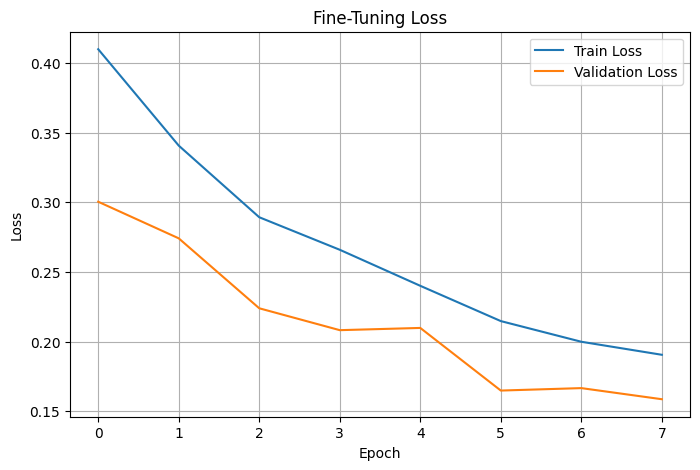

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(finetune_history["train_loss"], label="Train Loss")
plt.plot(finetune_history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

## 41. Plot Fine-Tuning Accuracy Curves

Accuracy curves help us compare training performance and validation performance.

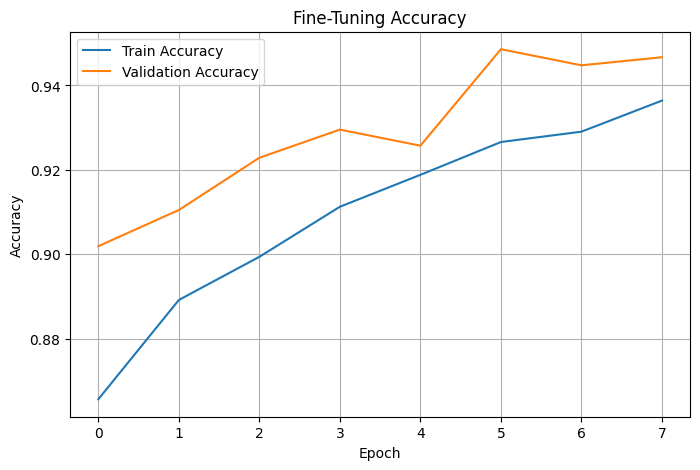

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(finetune_history["train_acc"], label="Train Accuracy")
plt.plot(finetune_history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 42. Final Test Evaluation

After training and fine-tuning, we now evaluate the best model on the test set.

The test set was not used during training or validation.

This gives us the most honest estimate of how well the model performs on unseen data.

In [52]:
# Load best fine-tuned checkpoint
best_checkpoint = torch.load(
    best_finetuned_checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(DEVICE)

print("Loaded best fine-tuned checkpoint.")
print("Training stage:", best_checkpoint["training_stage"])
print("Best validation accuracy:", best_checkpoint["val_accuracy"])
print("Best checkpoint epoch:", best_checkpoint["epoch"])

Loaded best fine-tuned checkpoint.
Training stage: fine_tuned_layer4
Best validation accuracy: 0.9485714285714286
Best checkpoint epoch: 6


## 43. Evaluate Model on Test Set

Now we calculate test loss and test accuracy.

This number should be reported as the final baseline performance of the model.

In [54]:
# Test Loss and Accuracy

test_loss, test_acc = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Accuracy (%): {test_acc * 100:.2f}%")

Final Test Loss: 0.1730
Final Test Accuracy: 0.9396
Final Test Accuracy (%): 93.96%


## 44. Collect Predictions from Test Set

To calculate detailed metrics, we collect:

- true labels
- predicted labels
- confidence scores
- probability distributions

These will be used for confusion matrix, precision, recall, F1-score, and error analysis.

In [55]:
@torch.no_grad()
def collect_predictions(model, data_loader, device):
    """
    Collects model predictions from a DataLoader.

    Returns:
        all_true_labels: Tensor of true class indices.
        all_pred_labels: Tensor of predicted class indices.
        all_confidences: Tensor of highest softmax probability per image.
        all_probabilities: Tensor of full class probabilities.
    """

    model.eval()

    all_true_labels = []
    all_pred_labels = []
    all_confidences = []
    all_probabilities = []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        confidences, predicted_labels = torch.max(probabilities, dim=1)

        all_true_labels.append(labels.cpu())
        all_pred_labels.append(predicted_labels.cpu())
        all_confidences.append(confidences.cpu())
        all_probabilities.append(probabilities.cpu())

    all_true_labels = torch.cat(all_true_labels)
    all_pred_labels = torch.cat(all_pred_labels)
    all_confidences = torch.cat(all_confidences)
    all_probabilities = torch.cat(all_probabilities)

    return all_true_labels, all_pred_labels, all_confidences, all_probabilities


true_labels, pred_labels, confidences, probabilities = collect_predictions(
    model=model,
    data_loader=test_loader,
    device=DEVICE
)

print("Number of test samples:", len(true_labels))
print("Number of predictions:", len(pred_labels))
print("Probability tensor shape:", probabilities.shape)

Number of test samples: 1060
Number of predictions: 1060
Probability tensor shape: torch.Size([1060, 10])


## 45. Confusion Matrix

A confusion matrix shows where the model is correct and where it gets confused.

Rows represent true classes.

Columns represent predicted classes.

The diagonal values show correct predictions.

Off-diagonal values show mistakes.

In [56]:
def build_confusion_matrix(true_labels, pred_labels, num_classes):
    """
    Builds a confusion matrix.

    Rows = true classes
    Columns = predicted classes
    """
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    for true, pred in zip(true_labels, pred_labels):
        cm[true, pred] += 1

    return cm


num_classes = len(test_dataset.classes)

confusion_matrix = build_confusion_matrix(
    true_labels=true_labels,
    pred_labels=pred_labels,
    num_classes=num_classes
)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
tensor([[106,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0, 105,   1,   0,   0,   0,   0,   0,   0,   0],
        [  0,   1, 105,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,  88,   9,   4,   0,   0,   2,   3],
        [  0,   0,   0,   0, 106,   0,   0,   0,   0,   0],
        [  0,   0,   0,   3,   9,  75,   2,   1,   1,  15],
        [  0,   0,   0,   0,   0,   0, 104,   0,   1,   1],
        [  0,   0,   0,   0,   0,   0,   0, 106,   0,   0],
        [  0,   0,   0,   2,   0,   0,   1,   1,  97,   5],
        [  0,   0,   0,   1,   1,   0,   0,   0,   0, 104]])


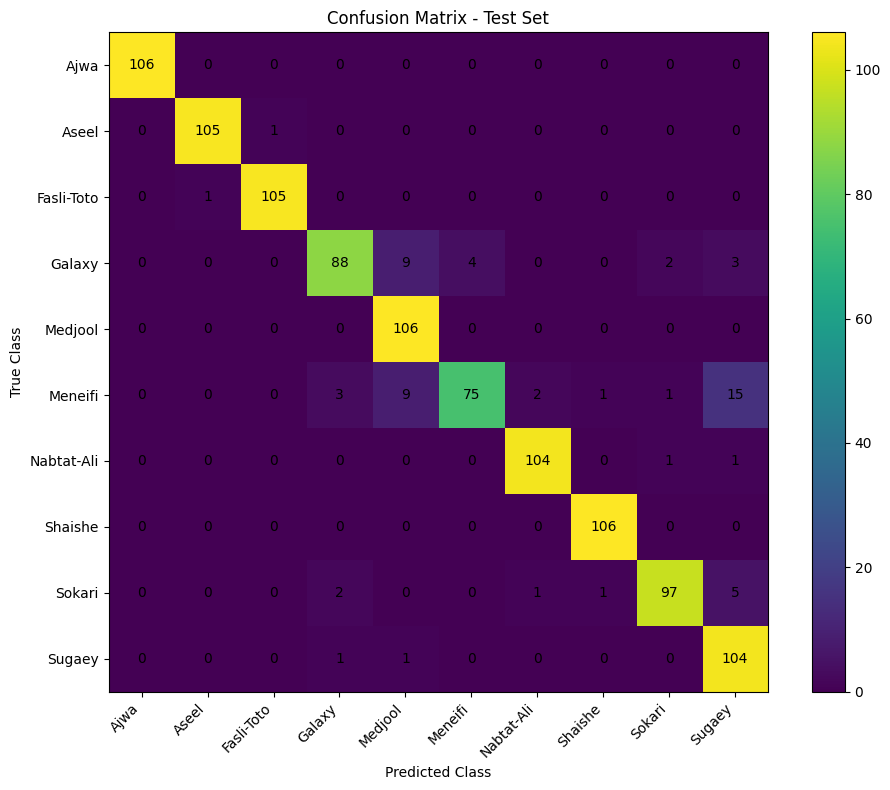

In [57]:
# plot confusion matrix
plt.figure(figsize=(10, 8))

plt.imshow(confusion_matrix, interpolation="nearest")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

class_names = test_dataset.classes

tick_marks = range(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Write numbers inside cells
for i in range(num_classes):
    for j in range(num_classes):
        value = confusion_matrix[i, j].item()
        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()